# Interactive Prototype

Goal: Create a functional MVP for field route planning and management.

Stages:
1. Region Input & Sub-Division
2. Automatic Target Search & Routing
3. Manual Adjustment
4. Select & Execute Plans

## Region Input & Sub-Division

- Get region outline
- Divide into work cells
- Tentative plan for depot locations
- 

### Dummy Region Shapefile

At this point, we do not actually have a shapefile of the target region. The following two Jupyter cells will generate one using the outline of the orthophoto we have created. 

Load this as the "shapefile" which will define our working region. 

In [1]:
region_image_path = '../input/IGNORE_Brewster-2024-all-orthophoto-UTM-32613.tif'
region_contour_shapefile = '../input/interactive_proto/region_contour.shp'
region_contour_geojson = '../input/interactive_proto/region_contour.geojson'


region_crs = 32613 # Use this everywhere for consistency
visualization_crs = 4326 # Use this when we need leaflet visualizations
simplification_tolerance = 5


In [2]:
import sys
import geopandas as gpd
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

### Create Voronoi Partitioning, Solve for Depots

- [x] Display region outline
- [x] Display region partition cells, centroids
- [x] Find and indicate depot locations
- [ ] Plan routes (pre-target adjustment CV) 

In [19]:
# Cell generation parameters
target_area_acres = 0.5
# target_area_acres = 1.5
# target_area_acres = 2.5

target_area_sqm = target_area_acres * 4046.86
max_iterations = 15 # Cycles to find improved partition
voronoi_partition_filename = '../input/interactive_proto/voronoi_partition.geojson'
voronoi_centroids_filename = '../input/interactive_proto/voronoi_centroids.geojson'

# Depot placement parameters
depot_radius = 225  # Max distance a depot can cover
grid_density = 4
depots_filename = '../input/interactive_proto/depot_points.geojson'


# Target detection parameters
binary_mask_path = "../outputs/region_binary_mask.tif"
region_orthophoto_filename = '../input/IGNORE_Brewster-2024-all-orthophoto-UTM-32613.tif'
targets_plants_filename = '../input/interactive_proto/targets.geojson'

# Macro route planning parameters
t_max_distance = 850  # Max distance per trip (meters)
t_distance_slack = 50
t_distance_slack_penalty = 10_000
t_slack_routes = 5
t_num_vehicles = 25
macro_routes_filename = '../input/interactive_proto/macro_routes.geojson'


In [20]:
from plant_search.region_partition import centroidal_voronoi_tessellation
from macro_planning.depot_placement import find_depots, assign_cells_to_depot

region_outline_gdf = gpd.read_file(region_contour_shapefile)
simplified_polygon = region_outline_gdf.geometry.iloc[0]
num_cells = int(simplified_polygon.area / target_area_sqm) # How many cells to generate

# Divide region into voronoi cells
cell_gdf = centroidal_voronoi_tessellation(simplified_polygon, num_cells, max_iterations)

# Find depots to cover all cells
depots_gdf = find_depots(depot_radius, cell_gdf, region_outline_gdf, grid_density)
assign_cells_to_depot(depots_gdf, cell_gdf) # Updates both GDFs in place

# for depot_id, depot in updated_cell_gdf.iterrows():
#     print(f'{depot_id}: {depot["closest_depot"]}')

Reached maximum iterations without full convergence.


### Find Targets

Testing multiple approaches:
1. From full-sized orthophoto
2. From downscaled orthophoto
3. From pre-computed binary mask

In [21]:
from plant_search.image_preprocess import correct_binary_mask, identify_targets
from plant_search.load_image import load_image
import rasterio

# Approach 3: from full-sized orthophoto
image, transform, bounds, image_crs = load_image(region_orthophoto_filename)

with rasterio.open(binary_mask_path) as src:
    binary_mask = src.read(1)  # Read the first band
    
full_binary_mask = correct_binary_mask(binary_mask, image.shape)
targets_gdf = identify_targets(full_binary_mask, transform)

# # del full_binary_mask # Gimme back my RAM
# print(f"Binary mask dimensions: {binary_mask.shape}")
# print(f"Number of targets (detected plants): {len(targets_gdf)}")

Image CRS - EPSG:32613


In [22]:
from plant_search.macro_planning import calculate_cell_workloads, targets_to_depots

# Associate each target with a parent cell
cell_gdf, targets_gdf = calculate_cell_workloads(cell_gdf, targets_gdf)
targets_gdf = targets_to_depots(cell_gdf, targets_gdf) # Associate each target w/ a depot

In [36]:
from macro_planning.trip_routing import create_distance_matrix, solve_basic_vrp, routes_to_gdf
from macro_planning.visualize_routing import plot_vrp_solution
from pandas import concat

target_data = {
    "core": {
        "num_vehicles": t_num_vehicles,
        "max_distance": t_max_distance,
        "distance_slack": t_distance_slack,
        "distance_slack_penalty": t_distance_slack_penalty,
        "slack_routes": t_slack_routes
    }
}

macro_routes_gdf_list = []

for depot_index in range(len(depots_gdf)):
    base_station_gdf = depots_gdf.iloc[[depot_index]]
    base_station_id = base_station_gdf.iloc[0]["depot_id"]
    station_cells_gdf = cell_gdf[cell_gdf["closest_depot"] == base_station_id].copy()
    
    compensate_for_targets = True
    t_distance_matrix = create_distance_matrix(station_cells_gdf, base_station_gdf, compensate_for_targets) # excluding intra-workload cost
    t_num_cells = len(t_distance_matrix)-1 # Number of stops

    target_data = {
        "core": {
            "distance_matrix": t_distance_matrix,
            "num_vehicles": t_num_vehicles,
            "depot_index": t_num_cells,
            "max_distance": t_max_distance,
            "distance_slack": t_distance_slack,
            "distance_slack_penalty": t_distance_slack_penalty,
            "slack_routes": t_slack_routes
        }
    }

    print_routes = False # Set to True to see individual route statistics
    target_routes = solve_basic_vrp(target_data, print_routes)



    if target_routes and isinstance(target_routes, list):
        # t_title = "Workload-Compensated Routes"
        # plot_vrp_solution(station_cells_gdf, t_distance_matrix, simplified_polygon, base_station_gdf, target_routes, t_title)
        depot_macro_routes_gdf = routes_to_gdf(station_cells_gdf, base_station_gdf, target_routes)
        macro_routes_gdf_list.append(depot_macro_routes_gdf)
    else:
        print("No solution found.")

macro_routes_gdf = gpd.GeoDataFrame(concat(macro_routes_gdf_list, ignore_index=True))

# print(macro_routes_gdf_list)
# macro_routes_gdf
print(macro_routes_gdf.keys())
# print(len(target_routes))
# for route in target_routes:
#     print(route)


No solution found.
No solution found.
No solution found.
No solution found.
No solution found.
No solution found.


ValueError: No objects to concatenate

In [ ]:
import geopandas as gpd

def associate_targets_with_routes(targets_gdf, macro_routes_gdf):
    # Initialize a new column for route_id in targets_gdf
    targets_gdf["route_id"] = None

    # Iterate through the macro_routes_gdf rows
    for _, route_row in macro_routes_gdf.iterrows():
        route_id = route_row["route_id"]
        route_cells = route_row["route_cells"]
        
        # Update targets_gdf: Assign route_id to targets whose parent_cell_id is in route_cells
        targets_gdf.loc[targets_gdf["parent_cell_id"].isin(route_cells), "route_id"] = route_id

    return targets_gdf

routed_targets_gdf = associate_targets_with_routes(targets_gdf, macro_routes_gdf)
# routed_targets_gdf

,geometry,bounding_box,parent_cell_id,closest_depot,route_id
0,POINT (-103.6038 30.25063),"POLYGON ((634323.7010862518 3347384.218589365,...",21.0,depot_128,depot_128_R1
2,POINT (-103.6036 30.25061),"POLYGON ((634345.135005016 3347382.0089318478,...",30.0,depot_128,depot_128_R1
3,POINT (-103.60336 30.25059),"POLYGON ((634365.8507770175 3347381.898448972,...",30.0,depot_128,depot_128_R1
4,POINT (-103.60332 30.25061),"POLYGON ((634372.1483717059 3347381.787966096,...",30.0,depot_128,depot_128_R1
5,POINT (-103.60397 30.25061),POLYGON ((634309.3933930561 3347381.5117589063...,21.0,depot_128,depot_128_R1
...,...,...,...,...,...
1201,POINT (-103.60134 30.24722),POLYGON ((634567.7605014587 3347007.7481898502...,73.0,depot_50,depot_50_R1
1202,POINT (-103.60134 30.24717),"POLYGON ((634568.1471958694 3347002.721218998,...",73.0,depot_50,depot_50_R1
1203,POINT (-103.60074 30.24716),"POLYGON ((634626.0408733562 3347001.947838867,...",72.0,depot_169,depot_169_R5
1204,POINT (-103.60125 30.24716),"POLYGON ((634576.9306831979 3347000.622044357,...",73.0,depot_50,depot_50_R1


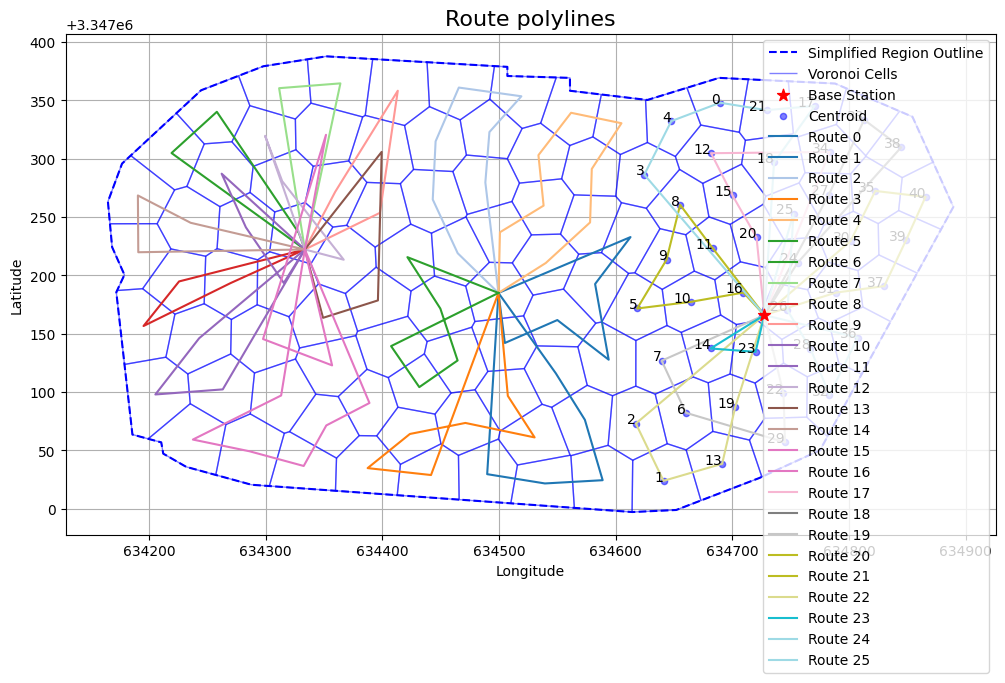

In [25]:
import math 
import matplotlib.pyplot as plt

base_station = base_station_gdf.geometry.iloc[0]  # Assuming single base station

# Plot centroids, region outline, and base station
fig, ax = plt.subplots(figsize=(12, 10))
region_outline_gdf.boundary.plot(ax=ax, color="blue", linestyle="--", label="Simplified Region Outline")
cell_gdf.boundary.plot(ax=ax, color="blue", linewidth=1, alpha=0.5, label="Voronoi Cells")  # Region cells
base_station_gdf.plot(ax=ax, color='red', markersize=80, marker='*', zorder=10, label='Base Station')

centroids = station_cells_gdf.cell_centroid
for i, centroid in enumerate(centroids):
    ax.scatter(centroid.x, centroid.y, color='blue', s=20, alpha=0.5, label='Centroid' if i == 0 else "")
    ax.text(centroid.x, centroid.y, str(i), fontsize=10, ha='right')

# Generate a colormap for routes
cmap = plt.get_cmap("tab20", len(macro_routes_gdf))  # Tab10 provides distinct colors
for route_idx, (index, row) in enumerate(macro_routes_gdf.iterrows()):
    ax.plot(*row.geometry.xy, color=cmap(route_idx), label=f"Route {index}")

ax.legend(loc="upper right", fontsize="small", title="Routes", ncol=2)

# Final plot details
ax.set_title("Route polylines", fontsize=16)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(loc='upper right', fontsize=10)
plt.grid(True)
plt.show()

#### Write Data to Files

1. Region cells
2.  Region cell centroids
3. Depot locations

In [26]:
cell_gdf_4326 = cell_gdf.copy().to_crs(visualization_crs)
# print(cell_gdf_4326.crs)

# Create a copy with only the 'geometry' column (Voronoi polygons)
voronoi_gdf = cell_gdf_4326.copy().drop(columns=["cell_centroid"])
voronoi_gdf.to_crs(visualization_crs, inplace=True)
voronoi_gdf.to_file(voronoi_partition_filename, driver="GeoJSON")

# Create a copy with only the 'cell_centroid' column and set it as the active geometry
centroid_gdf = cell_gdf_4326.copy().drop(columns=["geometry"])
centroid_gdf.set_geometry("cell_centroid", inplace=True)

centroid_gdf.set_crs(region_crs, inplace=True)  # Reset the CRS explicitly
centroid_gdf.to_crs(visualization_crs, inplace=True)  # Reset the CRS explicitly
centroid_gdf.to_file(voronoi_centroids_filename, driver="GeoJSON")

# Write Depot locations to file
depots_gdf.to_crs(visualization_crs, inplace=True)
depots_gdf.to_file(depots_filename, driver="GeoJSON")

# Write Targets locations to file
targets_gdf.to_crs(visualization_crs, inplace=True)
targets_gdf.to_file(targets_plants_filename, driver="GeoJSON")

# Write Macro-routes to file
macro_routes_gdf.to_crs(visualization_crs, inplace=True)
macro_routes_gdf.to_file(macro_routes_filename, driver="GeoJSON")

#### Data Interaction with Leaflet

In [27]:
from ipyleaflet import Circle, CircleMarker, LayerGroup

def create_depot_layers(depot_data):
    depot_layers = []

    for feature in depot_data["features"]:
        depot_plots = [] # Hold range, centerpoint circles
        coords = feature["geometry"]["coordinates"]
        properties = feature["properties"]
        depot_radius = properties.get("depot_radius", 0)  # Default to 0 if missing
        depot_id = properties.get("depot_id", "Unknown ID")
        depot_name = f'Depot {depot_id}'

        range_circle = Circle(
            location=[coords[1], coords[0]],  # GeoJSON uses (lon, lat), Folium expects (lat, lon)
            radius=depot_radius,  # Circle radius in meters
            color='black', fill=False, fill_color='#3366cc',
            fill_opacity=0.05, weight=1,
            tooltip=f"Depot ID: {depot_id}\nRadius: {depot_radius}m"
        )
        
        center_circle = CircleMarker(
            location=[coords[1], coords[0]],  # GeoJSON uses (lon, lat), Folium expects (lat, lon)
            radius=5,  # Circle radius in meters
            color='black', fill=True, fill_color='red',
            fill_opacity=0.9, weight=1,
            tooltip=f"Depot ID: {depot_id}\nRadius: {depot_radius}m"
        )

        depot_layergroup = LayerGroup(
            layers=(range_circle, center_circle),
            name=depot_name
        )
        depot_layers.append(depot_layergroup)
    
    return depot_layers

In [28]:
import geopandas as gpd
from ipyleaflet import (
    Map, GeoJSON, GeoData, Circle, LayerGroup,
    LayersControl, ScaleControl
)
from shapely.geometry import mapping, shape
import json

# Load the GeoJSON region outline
with open(region_contour_geojson, "r") as f:
    region_contour_data = json.load(f)
region_geometry = shape(region_contour_data['features'][0]['geometry'])
region_center = region_geometry.centroid

# Load Voronoi polygons
with open(voronoi_partition_filename, "r") as f:
    voronoi_data = json.load(f)

# Load centroids
with open(voronoi_centroids_filename, "r") as f:
    centroid_data = json.load(f)

# Load depot locations
with open(depots_filename, "r") as f:
    depot_data = json.load(f)

# print(region_contour_data)
print(voronoi_data)
# print(centroid_data)
# print(depot_data)




m = Map(center=(region_center.y, region_center.x), zoom=16)

# Add the region border to the map
region_layer = GeoJSON(
    data=region_contour_data, 
    style={'color': 'green', 'fillOpacity': 0.2, 'weight': 3},
    name=region_contour_data['name'])
m.add_layer(region_layer)

# Add Voronoi polygons
voronoi_layer = GeoJSON(
    data=voronoi_data, 
    style={'color': 'blue', 'fillColor': 'lightblue', 'opacity': 0.5, 'weight': 2},
    name=voronoi_data['name'])
m.add_layer(voronoi_layer)

# Add centroids
centroid_layer = GeoJSON(
    data=centroid_data, 
    style={'color': 'black', 'radius':3, 'fillColor': '#3366cc', 'opacity':0.5, 'weight':1.9, 'dashArray':'2', 'fillOpacity':0.6},
    hover_style={'fillColor': 'red' , 'fillOpacity': 0.2},
    point_style={'radius': 3, 'color': 'red', 'fillOpacity': 0.8, 'fillColor': 'blue', 'weight': 3},
    name=centroid_data['name'])
centroid_layer.visible = False  # Set layer to hidden
m.add_layer(centroid_layer)

# Plot depot circles
depot_layers = create_depot_layers(depot_data)
for depot_layer in depot_layers:
    m.add(depot_layer)


m.add_control(LayersControl(position='topright'))
m.add(ScaleControl(position='bottomleft'))
m # Display the map

{'type': 'FeatureCollection', 'name': 'voronoi_partition', 'crs': {'type': 'name', 'properties': {'name': 'urn:ogc:def:crs:OGC:1.3:CRS84'}}, 'features': [{'type': 'Feature', 'properties': {'cell_id': 0, 'associated_depots': ['depot_128'], 'closest_depot': 'depot_128', 'target_count': 19, 'intra_workload': 131.93345598486454}, 'geometry': {'type': 'Polygon', 'coordinates': [[[-103.60490730746969, 30.249657648407563], [-103.60506628695161, 30.24939821149538], [-103.60548636926535, 30.24940204634456], [-103.60550211222898, 30.24957322359244], [-103.60537224400474, 30.249865920578127], [-103.60529418627416, 30.24992724379856], [-103.60490730746969, 30.249657648407563]]]}}, {'type': 'Feature', 'properties': {'cell_id': 1, 'associated_depots': ['depot_128'], 'closest_depot': 'depot_128', 'target_count': 17, 'intra_workload': 145.6833706892118}, 'geometry': {'type': 'Polygon', 'coordinates': [[[-103.60520242697926, 30.248896985337836], [-103.60491775830154, 30.248697069427205], [-103.60500299

Map(center=[30.24893165719689, -103.6019209136208], controls=(ZoomControl(options=['position', 'zoom_in_text',…

## Minimal Depot Interactions

In [29]:
def depot_selection_layers(depot_data, cell_data):
    depot_layers = {} # dict, where key is depot_id

    for feature in depot_data["features"]:
        depot_plots = [] # Hold range, centerpoint circles
        coords = feature["geometry"]["coordinates"]
        properties = feature["properties"]
        depot_radius = int(properties.get("depot_radius", 0))  # Default to 0 if missing
        min_encl_radius = int(properties.get("min_enclosing_rad", 0))  # Default to 0 if missing
        valid_depot_range = (depot_radius-min_encl_radius) if min_encl_radius>0 else 0

        depot_id = properties.get("depot_id", "Unknown ID")
        depot_name = f'Depot {depot_id}'

        # Find cells associated with each depot for coloration
        associated_cells = cell_data.copy()
        associated_cells['features'] = [feature for feature in cell_data['features']
                                        if feature['properties']['closest_depot'] == depot_id]

        # Add highlight to cells in depot range
        cells_layer = GeoJSON(
            data=associated_cells, 
            style={'color': 'red', 'fillColor': 'lightblue', 'opacity': 0.5, 'weight': 2},
            # style_callback=color_cells,
            name=associated_cells['name'])


        # Maximum range of depot
        range_circle = Circle(
            location=[coords[1], coords[0]],  # GeoJSON uses (lon, lat), Folium expects (lat, lon)
            radius=depot_radius,  # Circle radius in meters
            color='black', fill=False, fill_color='#3366cc',
            fill_opacity=0.05, weight=1,
            tooltip=f"Depot ID: {depot_id}\nRadius: {depot_radius}m"
        )

        # Plot our minimum enclosing circle
        min_enclosing_circle = Circle(
            location=[coords[1], coords[0]],  # GeoJSON uses (lon, lat), Folium expects (lat, lon)
            radius=min_encl_radius,  # Circle radius in meters
            color='green', fill=False, fill_color='#3366cc',
            fill_opacity=0.05, weight=1, opacity=0.15,
            tooltip=f"Depot ID: {depot_id}\nRadius: {min_encl_radius}m"
        )
        
        # All valid depot placements to cover all cells
        valid_depots_circle = Circle(
            location=[coords[1], coords[0]],  # GeoJSON uses (lon, lat), Folium expects (lat, lon)
            radius=valid_depot_range,  # Circle radius in meters
            color='green', fill=True, fill_color='green',
            fill_opacity=0.1, weight=1, opacity=0.35,
            tooltip=f"Valid depot range: {depot_id}\nRadius: {valid_depot_range}m"
        )

        center_circle = CircleMarker(
            location=[coords[1], coords[0]],  # GeoJSON uses (lon, lat), Folium expects (lat, lon)
            radius=5,  # Circle radius in meters
            color='black', fill=True, fill_color='red',
            fill_opacity=0.9, weight=1,
            tooltip=f"Depot ID: {depot_id}\nRadius: {depot_radius}m"
        )

        depot_layergroup = LayerGroup(
            layers=(cells_layer, range_circle, min_enclosing_circle, 
                    valid_depots_circle, center_circle),
            name=depot_name
        )
        depot_layers[depot_id] = depot_layergroup
    
    return depot_layers

In [30]:
from ipyleaflet import Choropleth, GeoJSON, WidgetControl, FullScreenControl, GeomanDrawControl
from ipywidgets import Select, Dropdown
import matplotlib as plt
from shapely.geometry import mapping, shape
import json


# Load Data for mapping
# =====================

# Load the GeoJSON region outline
with open(region_contour_geojson, "r") as f:
    region_contour_data = json.load(f)
region_geometry = shape(region_contour_data['features'][0]['geometry'])
region_center = region_geometry.centroid

# Load Voronoi cells
with open(voronoi_partition_filename, "r") as f:
    voronoi_data = json.load(f)

# Load depot locations
with open(depots_filename, "r") as f:
    depot_data = json.load(f)



# Set up interactive layer selections
# ===================================
all_depot_layers = depot_selection_layers(depot_data, voronoi_data) # Dict of layer instances
list_depots = list(all_depot_layers.keys())

# Depot select widget
depot_select = Dropdown(
    options=list_depots,
    value=list_depots[0],
    description='Depot:',
    disabled=False
)

def on_depot_select(change):
    old_layer = all_depot_layers[change['old']]
    new_layer = all_depot_layers[change['new']]
    m2.substitute(old_layer, new_layer)

depot_select.observe(on_depot_select, names='value')




# Set up interactive map
# ======================
m2 = Map(center=(region_center.y, region_center.x), zoom=16, scroll_wheel_zoom=True)

# Add the region border to the map
region_layer = GeoJSON(
    data=region_contour_data, 
    style={'color': 'blue', 'fillOpacity': 0.05, 'weight': 2},
    name=region_contour_data['name'])
# region_layer.pmIgnore = True  # Lock this layer
m2.add(region_layer)

# Add Voronoi polygons
voronoi_layer = GeoJSON(
    data=voronoi_data, 
    style={'color': 'blue', 'fillColor': 'lightblue', 'opacity': 0.25, 'weight': 1},
    name=voronoi_data['name'])
voronoi_layer.pmIgnore = True  # Lock this layer
m2.add(voronoi_layer)

# Always keep depot points visible
depot_points = GeoJSON(
    data=depot_data,
    style={'color': 'black', 'radius':3, 'fillColor': '#3366cc', 'opacity':0.5, 'weight':1.9, 'dashArray':'2', 'fillOpacity':0.6},
    hover_style={'fillColor': 'red' , 'fillOpacity': 0.2},
    point_style={'radius': 3, 'color': 'red', 'fillOpacity': 0.8, 'fillColor': 'blue', 'weight': 3},
    name=depot_data['name']
)
m2.add(depot_points)

# Add depot selection dropdown widget
depot_select_control = WidgetControl(widget=depot_select, position='bottomright')
m2.add(depot_select_control)

# Add (interactive + dynamic) depot layer
depot_layer = all_depot_layers[depot_select.value] # Whichever is initially set
m2.add(depot_layer)

draw_control = GeomanDrawControl()
draw_control.circlemarker = {}
draw_control.rotate = False
m2.add(draw_control)

m2.add(FullScreenControl(position='topleft'))
m2.add(LayersControl(position='topright'))
m2.add(ScaleControl(position='bottomleft'))
m2

Map(center=[30.24893165719689, -103.6019209136208], controls=(ZoomControl(options=['position', 'zoom_in_text',…

In [31]:
depot_data

list_depots = [feature['properties']['depot_id'] for feature in depot_data['features']]
print(list_depots)

['depot_50', 'depot_128', 'depot_169']


## Display Targets w/ Cell Depot

- Each identified target is to be associated with a cell.
- Each cell is associated with a closest serving depot.

In [32]:
from ipyleaflet import GeoJSON, LayerGroup, CircleMarker, AntPath

def macro_route_display_layers(depot_data, macro_routes_data):
    macro_route_layers = {}
    for depot_feature in depot_data["features"]:
        properties = depot_feature["properties"]
        depot_id = properties.get("depot_id", "Unknown ID")
        coords = depot_feature["geometry"]["coordinates"]


        associated_routes = macro_routes_data.copy()
        associated_routes['features'] = [feature for feature in macro_routes_data['features']
                                        if feature['properties']['route_depot'] == depot_id]

        routes_layer = GeoJSON(
            data=associated_routes, 
            style={'color': 'green', 'fillColor': 'green', 'opacity': 0.25, 'weight': 1},
            hover_style={'color': 'red' , 'opacity': 0.8, 'weight': 3},
            name=f'Depot ID: {depot_id} macro routes'
        )

        center_circle = CircleMarker(
            location=[coords[1], coords[0]],  # GeoJSON uses (lon, lat), Folium expects (lat, lon)
            radius=5,  # Circle radius in meters
            color='black', fill=True, fill_color='red',
            fill_opacity=0.9, weight=1,
            tooltip=f"Depot ID: {depot_id}\nRadius: {depot_radius}m"
        )

        routes_layergroup = LayerGroup(
            layers=(routes_layer, center_circle),
            name=f"{depot_id} Routes"
        )
        macro_route_layers[depot_id] = routes_layergroup

    return macro_route_layers


def target_display_layers(depot_data, cell_data, targets_data):
    targets_layers = {}

    # 1) Associate each target with parent cell
    cell_targets = {} # dict, where key is depot_id
    for cell_feature in cell_data['features']:
        cell_properties = cell_feature['properties']
        cell_id = cell_properties.get("cell_id", "Unknown ID")

        # associated_targets = targets_data.copy()
        associated_targets = [feature for feature in targets_data['features']
                                        if feature['properties']['parent_cell_id'] == cell_id]
        cell_targets[cell_id] = associated_targets


    # 2) Associate each cell with depot
    depot_to_targets = {}
    for depot_feature in depot_data["features"]:
        properties = depot_feature["properties"]
        depot_id = properties.get("depot_id", "Unknown ID")
        coords = depot_feature["geometry"]["coordinates"]

        # Find cells associated with each depot for coloration
        associated_targets = targets_data.copy()
        associated_cell_ids = [feature['properties']['cell_id'] for feature in cell_data['features']
                                        if feature['properties']['closest_depot'] == depot_id]
        depot_targets = []
        for cell_id in associated_cell_ids:
            depot_targets += cell_targets[cell_id]
        associated_targets['features'] = depot_targets

        depot_to_targets[depot_id] = associated_targets

        # 3) Create targets layers

        # Display as Markers
        targets_layer = GeoJSON(
            data=associated_targets, 
            style={'color': 'red', 'fillColor': 'lightblue', 'opacity': 0.5, 'weight': 2},
            name=associated_targets['name'])
        
        # Display as Circle Marker points
        # targets_layer = GeoJSON(
        #     data=associated_targets,
        #     style={'color': 'black', 'radius':3, 'fillColor': '#3366cc', 'opacity':0.5, 'weight':1.9, 'fillOpacity':0.6},
        #     hover_style={'fillColor': 'red' , 'fillOpacity': 0.2},
        #     point_style={'radius': 3, 'color': 'red', 'fillOpacity': 0.8, 'fillColor': 'blue', 'weight': 3},
        #     name=associated_targets['name']
        # )
        
        center_circle = CircleMarker(
            location=[coords[1], coords[0]],  # GeoJSON uses (lon, lat), Folium expects (lat, lon)
            radius=5,  # Circle radius in meters
            color='black', fill=True, fill_color='red',
            fill_opacity=0.9, weight=1,
            tooltip=f"Depot ID: {depot_id}\nRadius: {depot_radius}m"
        )
        
        targets_layergroup = LayerGroup(
            layers=(targets_layer, center_circle),
            name=f"{depot_id} Targets"
        )
        targets_layers[depot_id] = targets_layergroup

    return targets_layers

In [33]:
from ipyleaflet import Choropleth, GeoJSON, WidgetControl, FullScreenControl, GeomanDrawControl
from ipywidgets import Select, Dropdown
import matplotlib as plt
from shapely.geometry import mapping, shape
import json
import time

# Load Data for mapping
# =====================

# Load the GeoJSON region outline
with open(region_contour_geojson, "r") as f:
    region_contour_data = json.load(f)
region_geometry = shape(region_contour_data['features'][0]['geometry'])
region_center = region_geometry.centroid

# Load Voronoi cells
with open(voronoi_partition_filename, "r") as f:
    voronoi_data = json.load(f)

# Load depot locations
with open(depots_filename, "r") as f:
    depot_data = json.load(f)

with open(targets_plants_filename, "r") as f:
    targets_data = json.load(f)

with open(macro_routes_filename, "r") as f:
    macro_routes_data = json.load(f)

# Set up interactive layer selections
# ===================================
all_depot_layers = depot_selection_layers(depot_data, voronoi_data) # Dict of layer instances
list_depots = list(all_depot_layers.keys())

# Targets associated with each depot
all_targets_layers = target_display_layers(depot_data, voronoi_data, targets_data)

# Routes associated with each depot
all_routes_layers = macro_route_display_layers(depot_data, macro_routes_data)

# Depot select widget
depot_select = Dropdown(
    options=list_depots,
    value=list_depots[0],
    description='Depot:',
    disabled=False
)


def focus_depot_on_select(selected_depot_id):
    
    # Extract the selected depot's feature from depot_data
    selected_depot = next(
        feature for feature in depot_data['features'] if feature['properties']['depot_id'] == selected_depot_id
    )
    
    # Get the depot's center coordinates (assuming Point geometry)
    depot_lon, depot_lat = selected_depot['geometry']['coordinates']
    
    # Get depot range (example property, replace with actual if different)
    depot_range = selected_depot['properties'].get('min_enclosing_rad', 400)  # Default to 500m if not provided
    buffer = -3  # Add an extra buffer
    
    # Convert range + buffer to approximate degree offsets
    lat_offset = (depot_range + buffer) / 111000 # 111,000 meters per degree of latitude
    # lon_offset = lat_offset / abs(depot_lat / 360) # Adjust for longitude scaling at latitude
    lon_offset = lat_offset / math.cos(math.radians(depot_lat))

    # Calculate bounding box
    min_lat = depot_lat - lat_offset
    max_lat = depot_lat + lat_offset
    min_lon = depot_lon - lon_offset
    max_lon = depot_lon + lon_offset
    
    # Fit the map to the bounding box
    m3.fit_bounds([[min_lat, min_lon], [max_lat, max_lon]])


def on_depot_select(change):
    # Change depot display layers
    old_layer = all_depot_layers[change['old']]
    new_layer = all_depot_layers[change['new']]
    m3.substitute(old_layer, new_layer)
    time.sleep(0.1) # Race condition in layer replacement

    # Swap out our displayed targets
    old_targets = all_targets_layers[change['old']]
    new_targets = all_targets_layers[change['new']]
    m3.substitute(old_targets, new_targets)
    time.sleep(0.1) # Race condition in layer replacement

    # Swap out our displayed routes
    old_routes = all_routes_layers[change['old']]
    new_routes = all_routes_layers[change['new']]
    m3.substitute(old_routes, new_routes)
    time.sleep(0.1) # Race condition in layer replacement

    selected_depot_id = change['new']
    # focus_depot_on_select(selected_depot_id)


depot_select.observe(on_depot_select, names='value')




# Set up interactive map
# ======================
m3 = Map(center=(region_center.y, region_center.x), 
         zoom=16, zoom_snap=0.25, zoom_delta=0.25, scroll_wheel_zoom=True
)

# Add the region border to the map
region_layer = GeoJSON(
    data=region_contour_data, 
    style={'color': 'blue', 'fillOpacity': 0.05, 'weight': 2},
    name=region_contour_data['name'])
# region_layer.pmIgnore = True  # Lock this layer
m3.add(region_layer)

# Add Voronoi polygons
voronoi_layer = GeoJSON(
    data=voronoi_data, 
    style={'color': 'blue', 'fillColor': 'lightblue', 'opacity': 0.25, 'weight': 1},
    name=voronoi_data['name'])
voronoi_layer.pmIgnore = True  # Lock this layer
m3.add(voronoi_layer)

# Always keep depot points visible
depot_points = GeoJSON(
    data=depot_data,
    style={'color': 'black', 'radius':3, 'fillColor': '#3366cc', 'opacity':0.5, 'weight':1.9, 'dashArray':'2', 'fillOpacity':0.6},
    hover_style={'fillColor': 'red' , 'fillOpacity': 0.2},
    point_style={'radius': 3, 'color': 'red', 'fillOpacity': 0.8, 'fillColor': 'blue', 'weight': 3},
    name=depot_data['name']
)
m3.add(depot_points)

# Add depot selection dropdown widget
depot_select_control = WidgetControl(widget=depot_select, position='bottomright')
m3.add(depot_select_control)

# Add (interactive + dynamic) depot layer
depot_layer = all_depot_layers[depot_select.value] # Whichever is initially set
m3.add(depot_layer)

# Add interactive targeting layer
targets_layer = all_targets_layers[depot_select.value]
m3.add(targets_layer)

# Add interactive routes layer
routes_layer = all_routes_layers[depot_select.value]
m3.add(routes_layer)

draw_control = GeomanDrawControl()
draw_control.circlemarker = {}
draw_control.rotate = False
draw_control.cut = False
draw_control.drag = False
m3.add(draw_control)

m3.add(FullScreenControl(position='topleft'))
m3.add(LayersControl(position='topright', collapsed=False))
m3.add(ScaleControl(position='bottomleft'))
m3

Map(center=[30.24893165719689, -103.6019209136208], controls=(ZoomControl(options=['position', 'zoom_in_text',…

In [34]:
# print(all_routes_layers.keys())
# print(all_routes_layers)
# print(depot_data)
print(m3.bounds)
print(m3.zoom)

()
16.0


## Show Routes from each Depot

- Show cells associated with each depot
- Show routes to cover all cells from each depot